In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

def imread_korean_path(path):
    try:
        img_array = np.fromfile(path, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        return img
    except Exception as e:
        print(f"이미지 읽기 오류: {e}")
        return None

def visualize_yolo_label(dataset_dir, split='train', image_name=None, class_mapping={0: 'Fire', 1: 'Smoke'}):
    img_dir = Path(dataset_dir) / split / "images"
    lbl_dir = Path(dataset_dir) / split / "labels"
    
    if not img_dir.exists() or not lbl_dir.exists():
        return

    if image_name:
        img_path = img_dir / image_name
        if not img_path.exists():
            print(f"{image_name} 없음.")
            return
    else:
        valid_extensions = {'.jpg', '.jpeg', '.png'}
        img_files = [f for f in img_dir.iterdir() if f.suffix.lower() in valid_extensions]
        
        if not img_files:
            return
            
        img_path = random.choice(img_files)
        print(f"{img_path.name}")
    
    img = imread_korean_path(str(img_path))
    if img is None:
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = img.shape
    
    lbl_path = lbl_dir / f"{img_path.stem}.txt"
    boxes = []
    
    if lbl_path.exists():
        with open(lbl_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if not parts: continue
                
                try:
                    cls_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    x_min = int((x_center - width / 2) * img_w)
                    y_min = int((y_center - height / 2) * img_h)
                    box_w = int(width * img_w)
                    box_h = int(height * img_h)
                    
                    boxes.append((cls_id, x_min, y_min, box_w, box_h))
                except Exception as e:
                    print(f"라벨 파싱 오류 ({lbl_path.name}): {e}")
                    continue
    else:
        print("Background")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)
    
    colors = {0: '#FF3333', 1: '#3399FF'} 
    
    for box in boxes:
        cls_id, x, y, w, h = box
        label_name = class_mapping.get(cls_id, f"Unknown({cls_id})")
        color = colors.get(cls_id, '#00FF00') 
        
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, label_name, color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor=color, edgecolor='none', alpha=0.8, pad=2))
    
    plt.title(f"Split: {split.upper()} | File: {img_path.name}\nSize: {img_w}x{img_h} | Objects: {len(boxes)}", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()



WEB00912.jpg


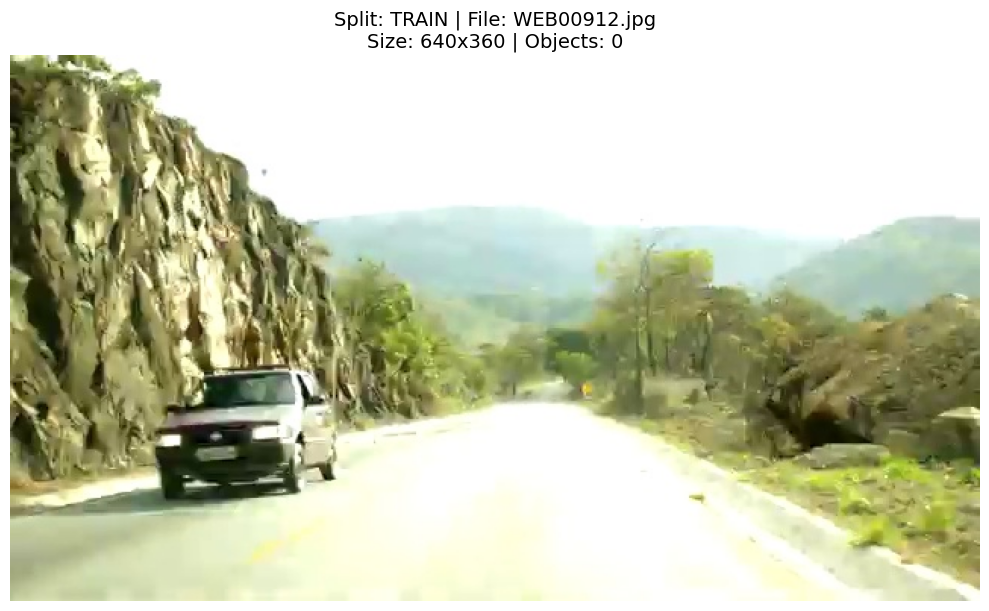

In [11]:
COMBINED_DATASET_DIR = "../dataset" 
final_mapping = {0: 'Fire', 1: 'Smoke'}

visualize_yolo_label(COMBINED_DATASET_DIR, split='train', class_mapping=final_mapping)

# visualize_yolo_label(COMBINED_DATASET_DIR, split='train', image_name='fire_001.jpg', class_mapping=final_mapping)